In [1]:
import numpy as np
import proplot as pplt
from pathlib import Path
from utils.data_processing import remove_padding
import cartopy.feature as cfeature

In [2]:
pred_path = your_file_path
real = np.load(pred_path)['data1']
pred = np.load(pred_path)['output1']

coordinate_path = "/datasets/bucket/dnstream/stats/coordinate.npz"
coor_data = np.load(coordinate_path)
lats, lons = coor_data['lat'], coor_data['lon']
lon2d, lat2d = np.meshgrid(lons, lats)

/home/cfeng/.conda/envs/pybkb/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/home/cfeng/.conda/envs/pybkb/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/home/cfeng/.conda/envs/pybkb/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/home/cfeng/.conda/envs/pybkb/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  wa

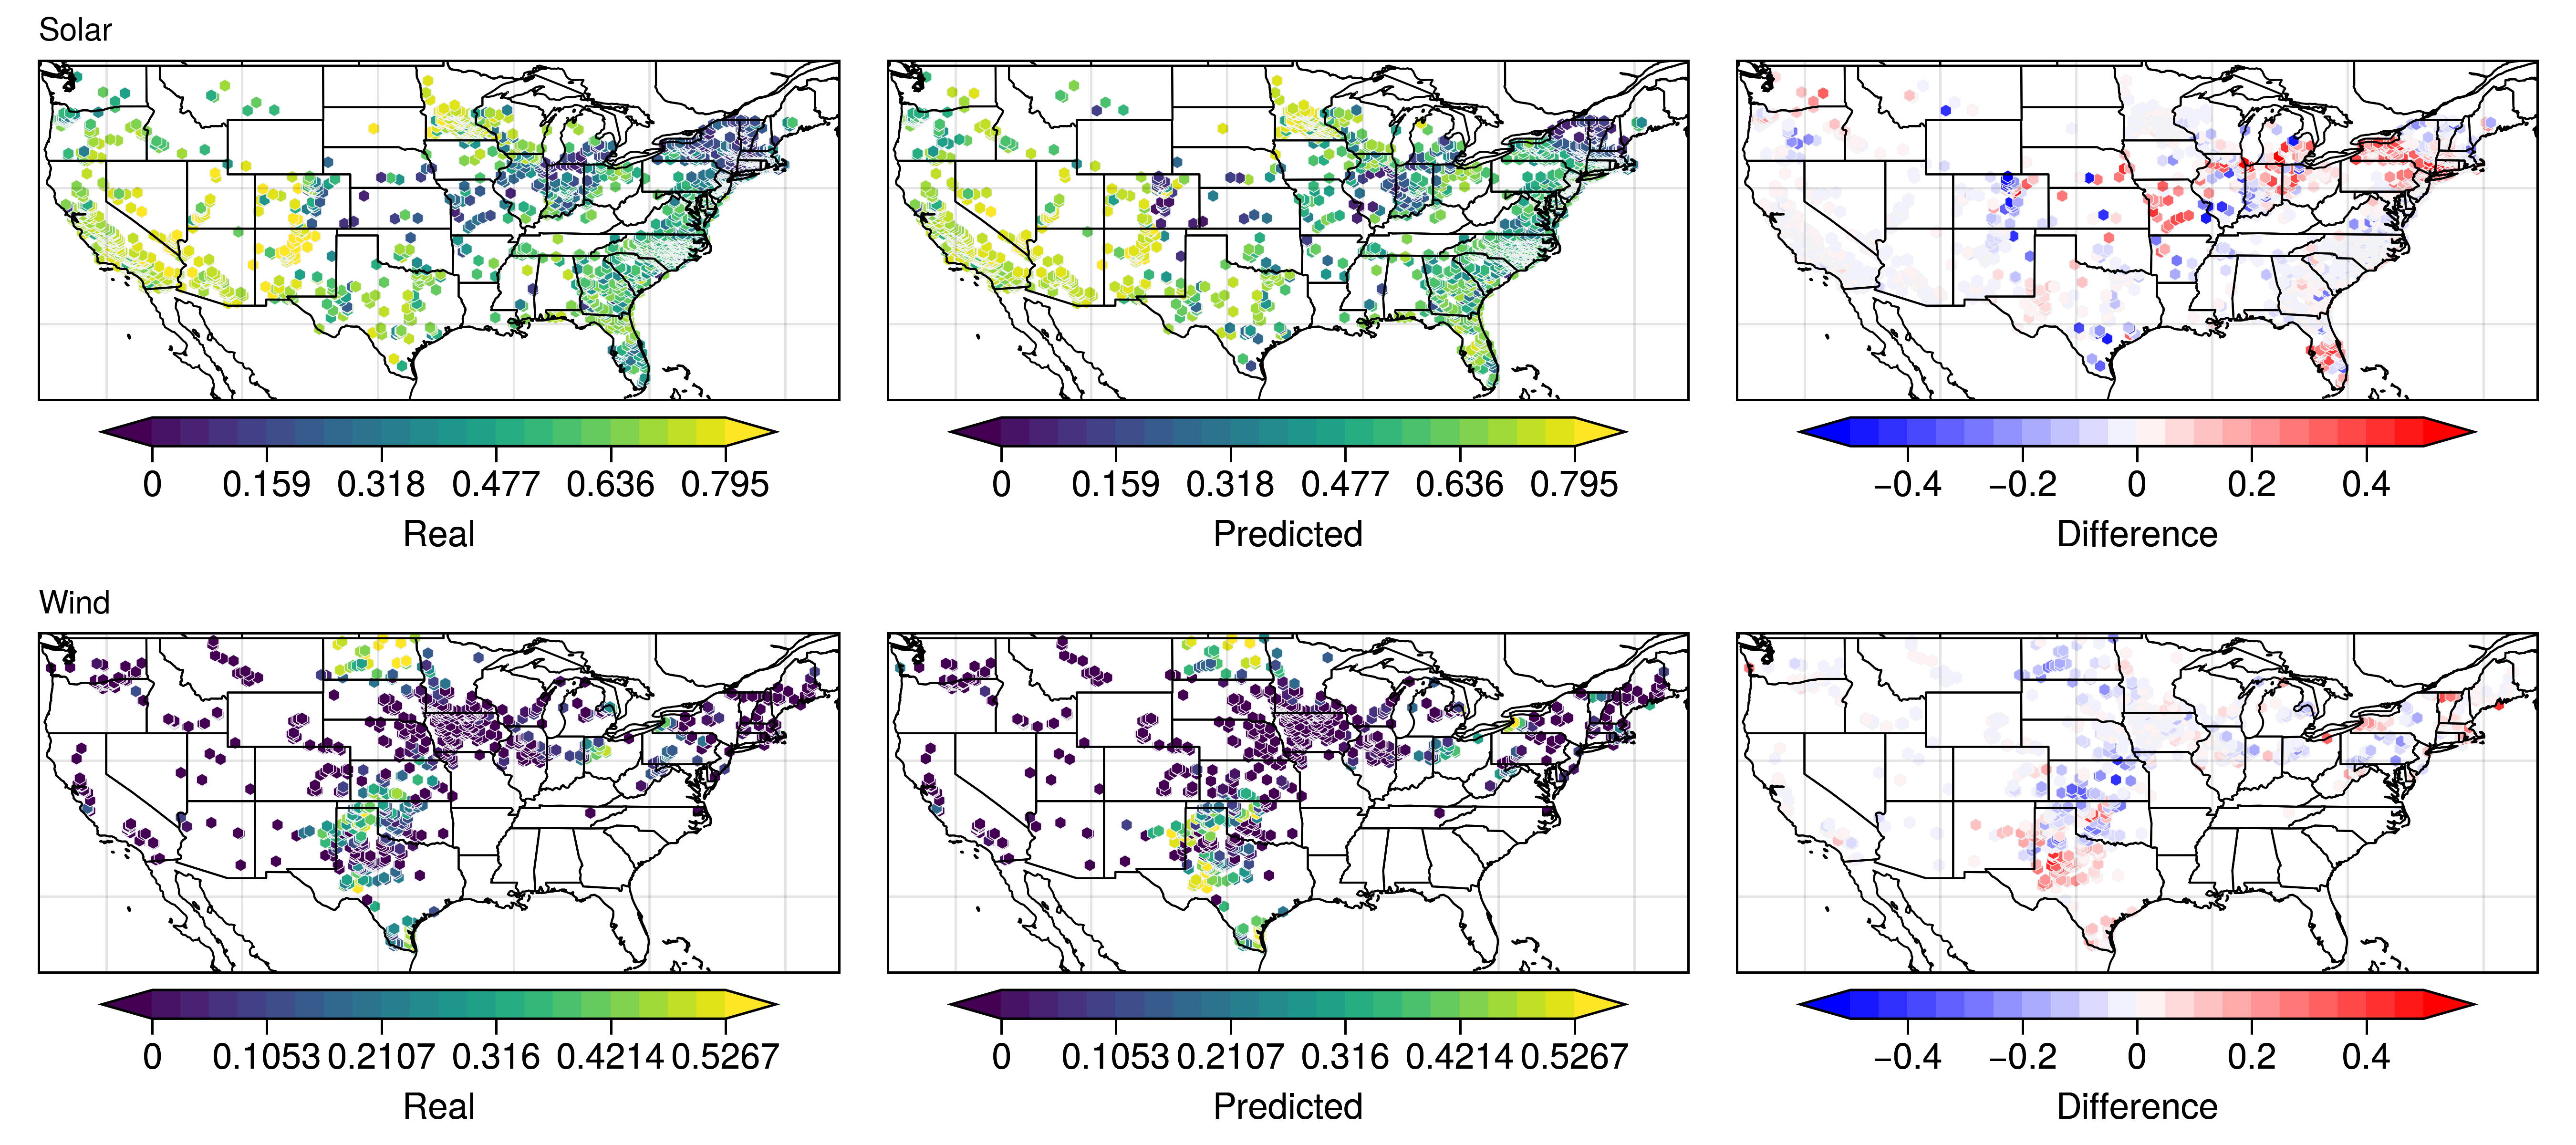

In [3]:
diff = pred - real
n_channels = real.shape[0]
fig, axs = pplt.subplots(nrows=n_channels, ncols=3, figsize=(9, 2 * n_channels), share=False, proj='cyl',wspace=0.2,
                         lonlim=(lons[0], lons[-1]), latlim=(lats[0], lats[-1]), dpi=300)
fig.patch.set_facecolor('white')

channel_names = ['Solar','Wind']

for i in range(n_channels):
    vmin = 0
    vmax = np.nanpercentile([real[i], pred[i]], 98)
    absmax = np.nanmax(np.abs(diff[i]))
    absmin = np.nanmin(diff[i])
    for j in range(3):
        ax = axs[i, j]
        ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.5)
        ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=0.5)
        ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.5)
        if j == 0:
            data = real[i].copy()
            cmap = 'viridis'
            levels = np.linspace(vmin, vmax, 21)
        elif j == 1:
            data = pred[i].copy()
            cmap = 'viridis'
            levels = np.linspace(vmin, vmax, 21)
        else:
            data = diff[i].copy()
            cmap = 'bwr'
            levels = np.linspace(-0.5, 0.5, 21)
        fmask = ~np.isnan(data)
        m = ax.scatter(lon2d[fmask], lat2d[fmask], c=data[fmask], cmap=cmap,extend='both',
                       marker='h',levels=levels,s=10,edgecolors='gray1',linewidth=0.2)
        ax.format(lonlines=10, latlines=10)
        if j == 0:
            ax.colorbar(m, loc='b',label='Real', length=0.8, width=0.1)
            ax.format(title=channel_names[i], titleloc='l',titlesize=8)
        if j == 1:
            ax.colorbar(m, loc='b',label='Predicted', length=0.8, width=0.1)
        if j == 2:
            ax.colorbar(m, loc='b',label='Difference', length=0.8, width=0.1)
fig.show()